In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


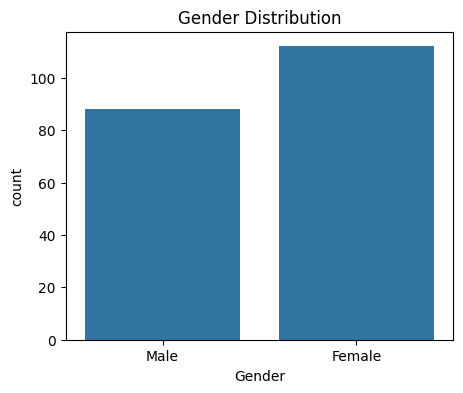

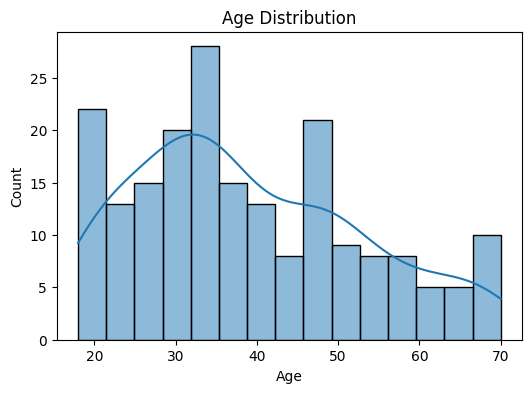

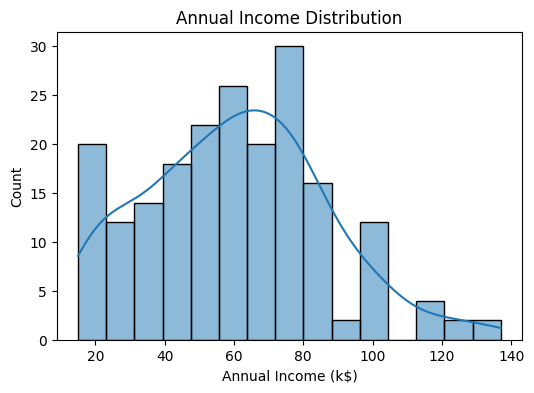

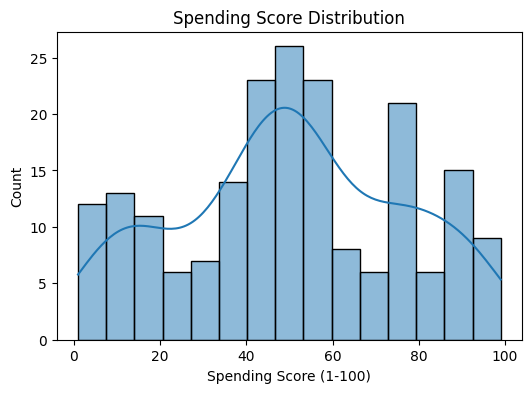

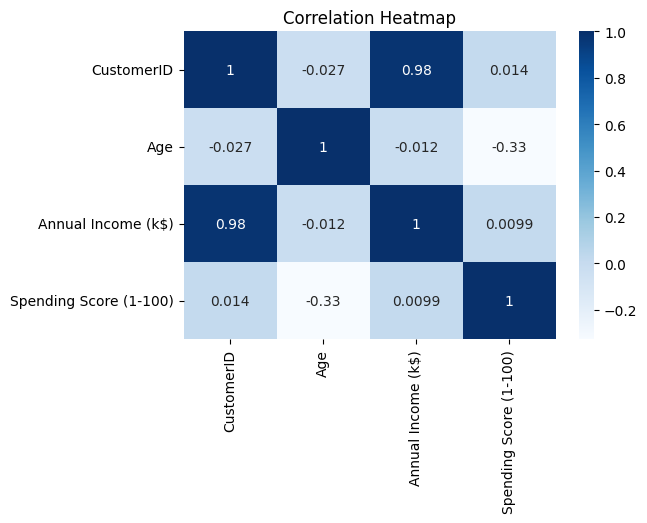

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

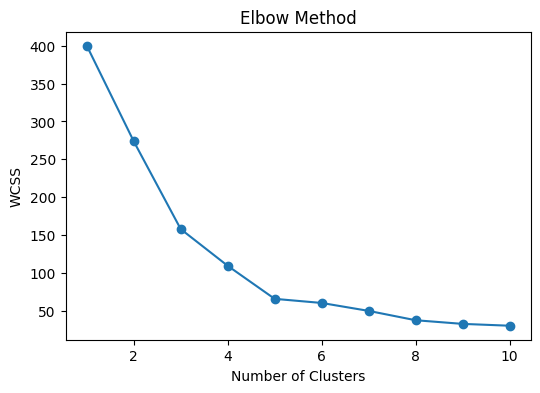

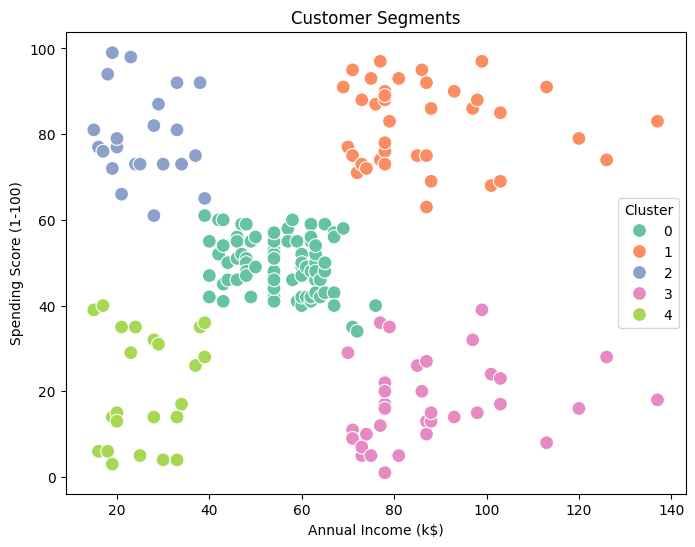

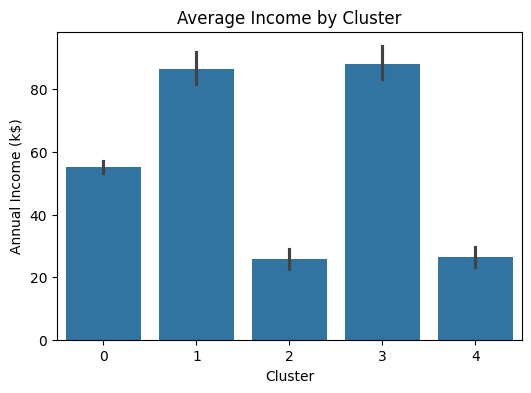

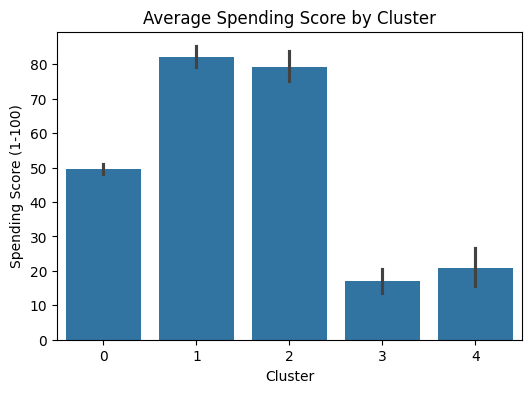

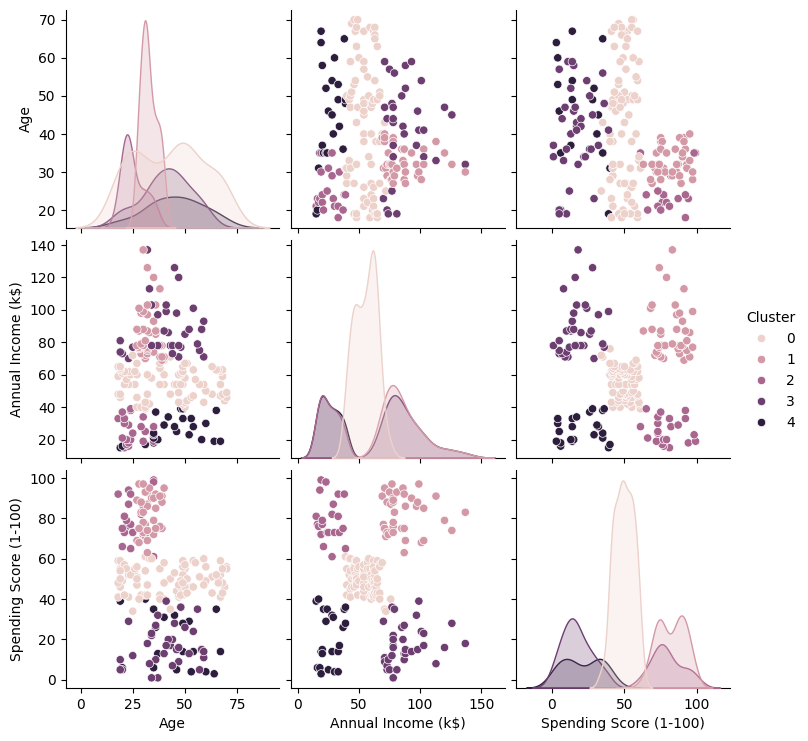

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../Mall_Customers.csv")

df.head()

df.info()

df.describe()

df.isnull().sum()

plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True)
plt.title("Spending Score Distribution")
plt.show()

plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")
plt.show()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

    plt.figure(figsize=(6,4))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)

plt.title("Customer Segments")

plt.show()

plt.figure(figsize=(6,4))

sns.barplot(
    x='Cluster',
    y='Annual Income (k$)',
    data=df
)

plt.title("Average Income by Cluster")

plt.show()

plt.figure(figsize=(6,4))

sns.barplot(
    x='Cluster',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Average Spending Score by Cluster")

plt.show()

sns.pairplot(
    df,
    vars=['Age','Annual Income (k$)','Spending Score (1-100)'],
    hue='Cluster'
)

plt.show()

